In [1]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv(r"C:\Users\Avishkar\Downloads\Heart_dataset.csv")
df

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,typical,145,233,1,2,150,0,2.3,3,0.0,fixed,No
1,2,67,1,asymptomatic,160,286,0,2,108,1,1.5,2,3.0,normal,Yes
2,3,67,1,asymptomatic,120,229,0,2,129,1,2.6,2,2.0,reversable,Yes
3,4,37,1,nonanginal,130,250,0,0,187,0,3.5,3,0.0,normal,No
4,5,41,0,nontypical,130,204,0,2,172,0,1.4,1,0.0,normal,No
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,299,45,1,typical,110,264,0,0,132,0,1.2,2,0.0,reversable,Yes
299,300,68,1,asymptomatic,144,193,1,0,141,0,3.4,2,2.0,reversable,Yes
300,301,57,1,asymptomatic,130,131,0,0,115,1,1.2,2,1.0,reversable,Yes
301,302,57,0,nontypical,130,236,0,2,174,0,0.0,2,1.0,normal,Yes


In [4]:
df.dtypes

Unnamed: 0      int64
Age             int64
Sex             int64
ChestPain      object
RestBP          int64
Chol            int64
Fbs             int64
RestECG         int64
MaxHR           int64
ExAng           int64
Oldpeak       float64
Slope           int64
Ca            float64
Thal           object
AHD            object
dtype: object

In [5]:
df.isna().sum()

Unnamed: 0    0
Age           0
Sex           0
ChestPain     0
RestBP        0
Chol          0
Fbs           0
RestECG       0
MaxHR         0
ExAng         0
Oldpeak       0
Slope         0
Ca            4
Thal          2
AHD           0
dtype: int64

In [15]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['Thal']= le.fit_transform(df['Thal'])

In [20]:
df['Thal'].fillna(df['Thal'].mode())

0      0
1      1
2      2
3      1
4      1
      ..
298    2
299    2
300    2
301    1
302    1
Name: Thal, Length: 303, dtype: int64

In [27]:
df['Ca'].fillna(df['Ca'].mean())
df['Ca'].isna().sum()

np.int64(0)

In [28]:
df.isna().sum()

Unnamed: 0    0
Age           0
Sex           0
ChestPain     0
RestBP        0
Chol          0
Fbs           0
RestECG       0
MaxHR         0
ExAng         0
Oldpeak       0
Slope         0
Ca            0
Thal          0
AHD           0
dtype: int64

In [46]:
df['ChestPain'] = le.fit_transform(df['ChestPain'])

In [47]:
df['AHD'] = le.fit_transform(df['AHD'])

In [48]:
df.head()

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal,AHD
0,1,63,1,3,145,233,1,2,150,0,2.3,3,0.0,0,0
1,2,67,1,0,160,286,0,2,108,1,1.5,2,3.0,1,1
2,3,67,1,0,120,229,0,2,129,1,2.6,2,2.0,2,1
3,4,37,1,1,130,250,0,0,187,0,3.5,3,0.0,1,0
4,5,41,0,2,130,204,0,2,172,0,1.4,1,0.0,1,0


In [49]:
x = df.drop('AHD',axis = 1)
x

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal
0,1,63,1,3,145,233,1,2,150,0,2.3,3,0.000000,0
1,2,67,1,0,160,286,0,2,108,1,1.5,2,3.000000,1
2,3,67,1,0,120,229,0,2,129,1,2.6,2,2.000000,2
3,4,37,1,1,130,250,0,0,187,0,3.5,3,0.000000,1
4,5,41,0,2,130,204,0,2,172,0,1.4,1,0.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,299,45,1,3,110,264,0,0,132,0,1.2,2,0.000000,2
299,300,68,1,0,144,193,1,0,141,0,3.4,2,2.000000,2
300,301,57,1,0,130,131,0,0,115,1,1.2,2,1.000000,2
301,302,57,0,2,130,236,0,2,174,0,0.0,2,1.000000,1


In [50]:
y = df['AHD']
y

0      0
1      1
2      1
3      0
4      0
      ..
298    1
299    1
300    1
301    1
302    0
Name: AHD, Length: 303, dtype: int64

In [51]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size = 0.80)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(242, 14)
(61, 14)
(242,)
(61,)


In [63]:
#DECISION TREE CLASSIFIER
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model_DTC = DecisionTreeClassifier()
model_DTC.fit(x_train,y_train)

DecisionTreeClassifier()

In [64]:
y_pred = model_DTC.predict(x_test)

In [65]:
print("Accuracy of this model is: ", accuracy_score(y_test,y_pred))

Accuracy of this model is:  0.6885245901639344


In [71]:
x

,Unnamed: 0,Age,Sex,ChestPain,RestBP,Chol,Fbs,RestECG,MaxHR,ExAng,Oldpeak,Slope,Ca,Thal
0,1,63,1,3,145,233,1,2,150,0,2.3,3,0.000000,0
1,2,67,1,0,160,286,0,2,108,1,1.5,2,3.000000,1
2,3,67,1,0,120,229,0,2,129,1,2.6,2,2.000000,2
3,4,37,1,1,130,250,0,0,187,0,3.5,3,0.000000,1
4,5,41,0,2,130,204,0,2,172,0,1.4,1,0.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
298,299,45,1,3,110,264,0,0,132,0,1.2,2,0.000000,2
299,300,68,1,0,144,193,1,0,141,0,3.4,2,2.000000,2
300,301,57,1,0,130,131,0,0,115,1,1.2,2,1.000000,2
301,302,57,0,2,130,236,0,2,174,0,0.0,2,1.000000,1


In [69]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,train_size = 0.80)
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(242, 14)
(61, 14)
(242,)
(61,)


In [72]:
#LOGISTIC REGRESSION
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

model_LR = LogisticRegression()
model_LR.fit(x_train,y_train)

D:\Anaconda\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [73]:
y_pred = model_LR.predict(x_test)

In [74]:
print("Accuracy of Logistic Regression Model is: ", accuracy_score(y_test,y_pred))

Accuracy of Logistic Regression Model is:  0.819672131147541


In [75]:
#LINEAR REGRESSION

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model_LiR = LinearRegression()
model_LiR.fit(x_train,y_train)

LinearRegression()

In [77]:
y_pred = model_LiR.predict(x_test)

In [78]:
print("MSE of Linear Regression Model is: ", mean_squared_error(y_test,y_pred))

MSE of Linear Regression Model is:  0.14158959493635812


In [80]:
#K-MEANS CLUSTERING

from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [90]:
x = df[['RestBP','Chol']]

kmeans = KMeans(n_clusters = 3, random_state = 0)
kmeans.fit(x)

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


KMeans(n_clusters=3, random_state=0)

In [84]:
df['Cluster'] = kmeans.labels_

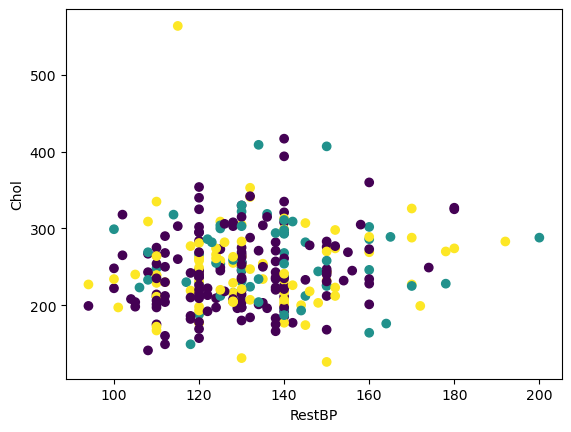

In [91]:
plt.scatter(x['RestBP'], x['Chol'], c=df['Cluster'])
plt.xlabel('RestBP')
plt.ylabel('Chol')
plt.show()